# Modeling

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally

## Table of Contents
1. Load preprocessed data
2. Baseline Models (Simple Train/Test)
3. Advanced Models (Simple Train/Test)
4. Feature Selection
5. Cross-Validation
6. Hyperparameter Tuning (GridSearchCV)
7. Final Model Comparision
8. Save the best model

## 1. Load preprocessed data

### Environment Setup

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score

from sklearn.model_selection import GridSearchCV

# settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

### Load preprocessed-only data
This is the data resulting from the preprocessing notebook.

In [2]:
# load data from preprocessing notebook
X_train_base = pd.read_csv('../data/processed/X_train.csv')
X_test_base = pd.read_csv('../data/processed/X_test.csv')
y_train_base = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test_base = pd.read_csv('../data/processed/y_test.csv').squeeze()

print("X_train_base preview:")
display(X_train_base.head(3))

print(f"X_train_base shape: {X_train_base.shape}")
print(f"X_test_base shape: {X_test_base.shape}")
print(f"y_train_base shape: {y_train_base.shape}")
print(f"y_test_base shape: {y_test_base.shape}")

X_train_base preview:


,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,0.60,0.6212,0.46,0.4179,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
1,0.60,0.5606,0.83,0.1045,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
2,0.44,0.4394,0.94,0.0000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False


X_train_base shape: (13903, 61)
X_test_base shape: (3476, 61)
y_train_base shape: (13903,)
y_test_base shape: (3476,)


### Load unscaled data with engineered features
This is the *unscaled* data resulting from the feature engineering notebook.

In [3]:
# load unscaled data from feature engineering notebook
X_train_fe_unscaled = pd.read_csv('../data/modeling/X_train.csv')
X_test_fe_unscaled = pd.read_csv('../data/modeling/X_test.csv')
y_train_fe_unscaled = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test_fe_unscaled = pd.read_csv('../data/modeling/y_test.csv').squeeze()

print("X_train_fe_unscaled preview:")
display(X_train_fe_unscaled.head(3))

print(f"X_train shape: {X_train_fe_unscaled.shape}")
print(f"X_test shape: {X_test_fe_unscaled.shape}")
print(f"y_train shape: {y_train_fe_unscaled.shape}")
print(f"y_test shape: {y_test_fe_unscaled.shape}")

X_train_fe_unscaled preview:


,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4,is_dawn,is_morning,is_afternoon,is_evening,rush_hour,temp_extreme,atemp_extreme,hum_extreme,windspeed_extreme,temp_diff,temp_windspeed,hum_windspeed
0,0.60,0.6212,0.46,0.4179,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0.0212,0.25074,0.192234
1,0.60,0.5606,0.83,0.1045,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,-0.0394,0.06270,0.086735
2,0.44,0.4394,0.94,0.0000,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,1,-0.0006,0.00000,0.000000


X_train shape: (13903, 73)
X_test shape: (3476, 73)
y_train shape: (13903,)
y_test shape: (3476,)


### Load scaled data with engineered features
This is the *scaled* data resulting from the feature engineering notebook.

In [4]:
# load scaled data from feature engineering notebook
X_train_fe_scaled = pd.read_csv('../data/modeling/X_train_standard.csv')
X_test_fe_scaled = pd.read_csv('../data/modeling/X_test_standard.csv')

print("X_train_standard preview:")
display(X_train_fe_scaled.head(3))

print(f"X_train_standard shape: {X_train_fe_scaled.shape}")
print(f"X_test_standard shape: {X_test_fe_scaled.shape}")

X_train_standard preview:


,temp,atemp,hum,windspeed,temp_diff,temp_windspeed,hum_windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4,is_dawn,is_morning,is_afternoon,is_evening,rush_hour,temp_extreme,atemp_extreme,hum_extreme,windspeed_extreme
0,0.534059,0.844346,-0.869396,1.873720,1.224320,2.182433,1.061084,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1
1,0.534059,0.491666,1.051129,-0.696151,-0.532689,-0.429919,-0.336170,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0
2,-0.296724,-0.213695,1.622096,-1.553047,0.592261,-1.300981,-1.484909,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,1


X_train_standard shape: (13903, 73)
X_test_standard shape: (3476, 73)


### Verify dataset shapes
Here, we check the final shapes of the three loaded datasets.

In [5]:
print(f'Training (baseline):  {X_train_base.shape}')
print(f'Training (with new features, unscaled):  {X_train_fe_unscaled.shape}')
print(f'Training (with new features, scaled):    {X_train_fe_scaled.shape}')
print(f'Test (with new features, unscaled):      {X_test_fe_scaled.shape}')

Training (baseline):  (13903, 61)
Training (with new features, unscaled):  (13903, 73)
Training (with new features, scaled):    (13903, 73)
Test (with new features, unscaled):      (3476, 73)


### Observations

- Dataset Shapes:
  - Training (baseline): 13,903 rows x 61 columns
  - Training (with new features, *unscaled*): 13,903 rows x 73 columns
  - Training (with new features, *scaled*): 13,903 rows x 73 columns
  - Test (with new features, *unscaled*): 3,476 rows x 73 columns
- The range for the target variable `cnt` is the minimum to maximum: 1-977
- Scaled or Unscaled:
  - Linear Regression will be run on both unscaled and scaled data to compare the results
  - Ridge and Lasso will be run on only scaled data
  - Decision Tree, Random Forest, and Gradient Boosting are tree-based algorithms, meaning they should only be run on the original (unscaled) data

## 2 - 3. Basline & Advanced Models
We will work with the following six model forms: 

Baseline:
- Linear Regression
- Decision Tree Regression

Advanced:
- Ridge Regression
- Lasso Regression
- Random Forest Regression
- Gradient Boosting Regression

In [6]:
results = []  # define empty list to store models

In [7]:
# function formatting model metrics
def model_metrics(model, model_name,
                  X_train_func, y_train_func,
                  X_test_func, y_test_func,
                  results_list,
                  output=True):

    # if model is GridSearchCV object, get the best fitted estimator
    fitted_model = model.best_estimator_ if hasattr(model, 'best_estimator_') else model

    if output:
        print(f'MODEL: {model_name}')

    # train metrics
    y_pred_train = fitted_model.predict(X_train_func)
    r2_train = r2_score(y_train_func, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train_func, y_pred_train))
    if output:
        print(f'\tTrain: R² = {r2_train:.4f}, RMSE = {rmse_train:.4f}')

    # test metrics
    y_pred_test = fitted_model.predict(X_test_func)
    r2_test = r2_score(y_test_func, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_func, y_pred_test))
    if output:
        print(f'\tTest:  R² = {r2_test:.4f}, RMSE = {rmse_test:.4f}\n')

    results_list.append({
        'Model': model_name,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'RMSE Δ (Test-Train)': rmse_test - rmse_train,
        'Train R²': r2_train,
        'Test R²': r2_test,
        'R² Δ (Test-Train)': r2_test - r2_train
    })

### Model 1: Linear Regression

We will have three baseline linear regression models: 
- `lr_base`, trained and tested on preprocessed-only data (no new features, no scaline)
- `lr_unsc`, trained and tested on data with engineered features, but no standardization   
- `lr_sc`, using data with engineered features. trained on standardized version, tested on the pre-standardized set

In [8]:
# LR baseline
lr_base = LinearRegression()
lr_base.fit(X_train_base, y_train_base)
model_metrics( lr_base, 'Linear Regression (baseline, no feature engineering)',
                X_train_base, y_train_base,
                X_test_base, y_test_base,
                results
                )

# LR (unscaled)
lr_unsc = LinearRegression()
lr_unsc.fit(X_train_fe_unscaled, y_train_fe_unscaled)
model_metrics(lr_unsc, 'Linear Regression (baseline, unscaled data)',
            X_train_fe_unscaled, y_train_fe_unscaled,
            X_test_fe_unscaled, y_test_fe_unscaled,
            results
            )

# LR (scaled)
lr_sc = LinearRegression()
lr_sc.fit(X_train_fe_scaled, y_train_fe_unscaled)
model_metrics(lr_sc, 'Linear Regression (baseline, scaled data)',
            X_train_fe_scaled, y_train_fe_unscaled,
            X_test_fe_scaled, y_test_fe_unscaled,
            results
            )

MODEL: Linear Regression (baseline, no feature engineering)
	Train: R² = 0.6853, RMSE = 101.8258
	Test:  R² = 0.6893, RMSE = 100.7828

MODEL: Linear Regression (baseline, unscaled data)
	Train: R² = 0.7128, RMSE = 97.2820
	Test:  R² = 0.7150, RMSE = 96.5234

MODEL: Linear Regression (baseline, scaled data)
	Train: R² = 0.7128, RMSE = 97.2820
	Test:  R² = 0.7150, RMSE = 96.5234



### Model 2: Ridge Regression

We will have one baseline ridge regression model: 
- `ridge_sc`, using data with engineered features. trained on standardized version, tested on the pre-standardized set    

Ridge regression performs partial feature seleciton and is imformative about unimportant features, so we run only the post-feature-engineering data.

In [9]:
# Ridge (scaled)
ridge_sc = Ridge(alpha=10.0)
ridge_sc.fit(X_train_fe_scaled, y_train_fe_unscaled)
model_metrics(ridge_sc, 'Ridge (baseline, scaled data)',
            X_train_fe_scaled, y_train_fe_unscaled,
            X_test_fe_scaled, y_test_fe_unscaled,
            results
            )

MODEL: Ridge (baseline, scaled data)
	Train: R² = 0.7127, RMSE = 97.2985
	Test:  R² = 0.7151, RMSE = 96.4970



### Model 3: Lasso Regression

We will have one baseline lasso regression model: 
- `lasso_sc`, using data with engineered features. trained on standardized version, tested on the pre-standardized set    

Lasso regression penalizes unimportant features essentially performing feature selection, so we use only the data with the new features and not the baseline dataset.

In [10]:
# Lasso (scaled)
lasso_sc = Lasso(alpha=0.01, max_iter=50000)
lasso_sc.fit(X_train_fe_scaled, y_train_fe_unscaled)
model_metrics(lasso_sc, 'Lasso (baseline, scaled data)',
            X_train_fe_scaled, y_train_fe_unscaled,
            X_test_fe_scaled, y_test_fe_unscaled,
            results
            )

MODEL: Lasso (baseline, scaled data)
	Train: R² = 0.7128, RMSE = 97.2861
	Test:  R² = 0.7152, RMSE = 96.4831



### Model 4: Decision Tree

We will have one baseline decision tree model: 
- `dt_unsc`, trained and tested on data with engineered features, but no standardization     

It is necessary to run the next three models, tree-based models, on unscaled data.

In [11]:
# Decision Tree (unscaled)
dt_unsc = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt_unsc.fit(X_train_fe_unscaled, y_train_fe_unscaled)
model_metrics(dt_unsc, 'Decision Tree (baseline, unscaled data)',
            X_train_fe_unscaled, y_train_fe_unscaled,
            X_test_fe_unscaled, y_test_fe_unscaled,
            results
            )

MODEL: Decision Tree (baseline, unscaled data)
	Train: R² = 0.9283, RMSE = 48.5965
	Test:  R² = 0.8845, RMSE = 61.4360



### Model 5: Random Forest

We will have one baseline random forest model: 
- `rf_unsc`, trained and tested on data with engineered features, but no standardization     

In [12]:
# Random Forest (unscaled)
rf_unsc = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=4950, n_jobs=-1)
rf_unsc.fit(X_train_fe_unscaled, y_train_fe_unscaled)
model_metrics(rf_unsc, 'Random Forest (baseline, unscaled data)',
            X_train_fe_unscaled, y_train_fe_unscaled,
            X_test_fe_unscaled, y_test_fe_unscaled,
            results
            )

MODEL: Random Forest (baseline, unscaled data)
	Train: R² = 0.9857, RMSE = 21.6713
	Test:  R² = 0.9408, RMSE = 43.9940



### Model 6: Gradient Boosting

We will have one baseline gradient boosting model: 
- `rf_unsc`, trained and tested on data with engineered features, but no standardization     

In [13]:
# Gradient Boosting (unscaled)
gb_unsc = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                    learning_rate=0.1, random_state=4950)
gb_unsc.fit(X_train_fe_unscaled, y_train_fe_unscaled)
model_metrics(gb_unsc, 'Gradient Boosting (baseline, unscaled data)',
            X_train_fe_unscaled, y_train_fe_unscaled,
            X_test_fe_unscaled, y_test_fe_unscaled,
            results
            )

MODEL: Gradient Boosting (baseline, unscaled data)
	Train: R² = 0.9062, RMSE = 55.5961
	Test:  R² = 0.8999, RMSE = 57.1887



### Baseline Model Results Comparison Table

,Model,Train RMSE,Test RMSE,RMSE Δ (Test-Train),Train R²,Test R²,R² Δ (Test-Train)
6,"Random Forest (baseline, unscaled data)",21.671267,43.993977,22.322710,0.985748,0.940791,-0.044956
7,"Gradient Boosting (baseline, unscaled data)",55.596138,57.188732,1.592594,0.906198,0.899949,-0.006249
5,"Decision Tree (baseline, unscaled data)",48.596504,61.436011,12.839507,0.928331,0.884536,-0.043795
4,"Lasso (baseline, scaled data)",97.286131,96.483139,-0.802992,0.712774,0.715224,0.002450
3,"Ridge (baseline, scaled data)",97.298495,96.497045,-0.801451,0.712701,0.715142,0.002441
1,"Linear Regression (baseline, unscaled data)",97.281962,96.523361,-0.758602,0.712799,0.714987,0.002188
2,"Linear Regression (baseline, scaled data)",97.281962,96.523361,-0.758602,0.712799,0.714987,0.002188
0,"Linear Regression (baseline, no feature engineering)",101.825821,100.782819,-1.043002,0.685343,0.689277,0.003934


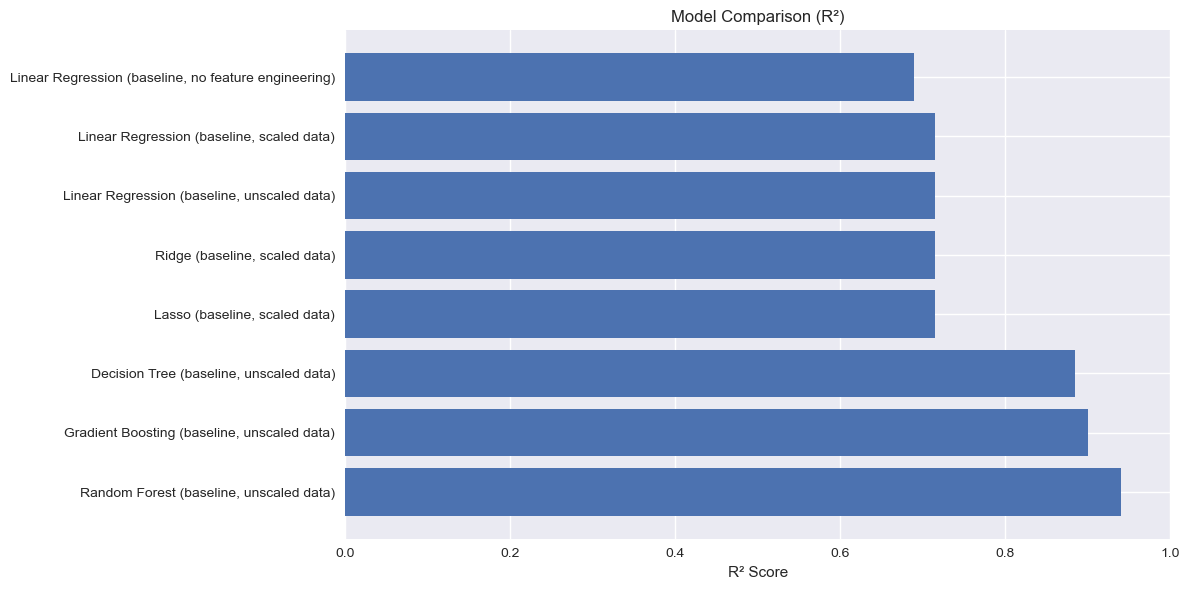

In [14]:
# create comparison table
result_df = pd.DataFrame(results)
result_df = result_df.sort_values('Test R²', ascending=False)
display(result_df)

# barplot of r-squared for all models
f, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(result_df['Model'], result_df['Test R²'])
ax.set_xlabel('R² Score')
ax.set_title('Model Comparison (R²)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

### Observations

- **Random Forest** is the best performing model with its metrics containing the lowest test RMSE (\~43.99) and the highest test R² (\~0.941), indicating strong predictive performance when comparing against other models.
  - Despite this, the model still shows signs of overfitting with its training RMSE (\~21.67) is much lower than the test RMSE, and the R² drops from \~0.986 (train) to \~0.941 (test). This gap suggests the model is fitting the training data too closely and not generalizing as well to unseen data.

- Gradient Boosting performs well with minimal overfitting. The train and test RMSE values (\~55.6 vs \~57.2) and R² values are very close, indicating good generalization. While it does not outperform Random Forest in accuracy, it is much more stable.

Models to Tune:
- Ridge Regression, because while it currently underfits, tuning the regularization strength ($\alpha$) may help it better balance bias and variance and extract more signal from the features.
- Random Forest, because it has the best performance but suffers from overfitting. Hyperparameter tuning could improve generalization.
- Gradient Boosting, because it already generalizes well and may surpass Random Forest with careful tuning.

## 4. Feature Selection
### Feature Refinement - Dropping Uninformative Features

STEP 1: ------------------------------------


rush_hour         0.451315
is_evening        0.438567
temp              0.402131
atemp             0.398975
hum               0.322471
hr_17             0.318461
temp_windspeed    0.302093
hr_18             0.268344
temp_diff         0.257793
yr_0              0.248425
yr_1              0.248425
season_1          0.245624
is_afternoon      0.206273
hr_4              0.203672
hr_3              0.201380
Name: cnt, dtype: float64


STEP 2: ------------------------------------
Features zeroed by Lasso:
temp_diff
yr_1
hr_6
hr_11
hr_15
hr_19
weekday_3
is_dawn

STEP 3: ------------------------------------
Highly correlated feature pairs (>0.85):


,Feature 1,Feature 2,Correlation
3,holiday_0,holiday_1,-1.000000
0,temp,atemp,0.988539
2,workingday_0,workingday_1,-1.000000
1,yr_0,yr_1,-1.000000



STEP 4: ------------------------------------


<Axes: >

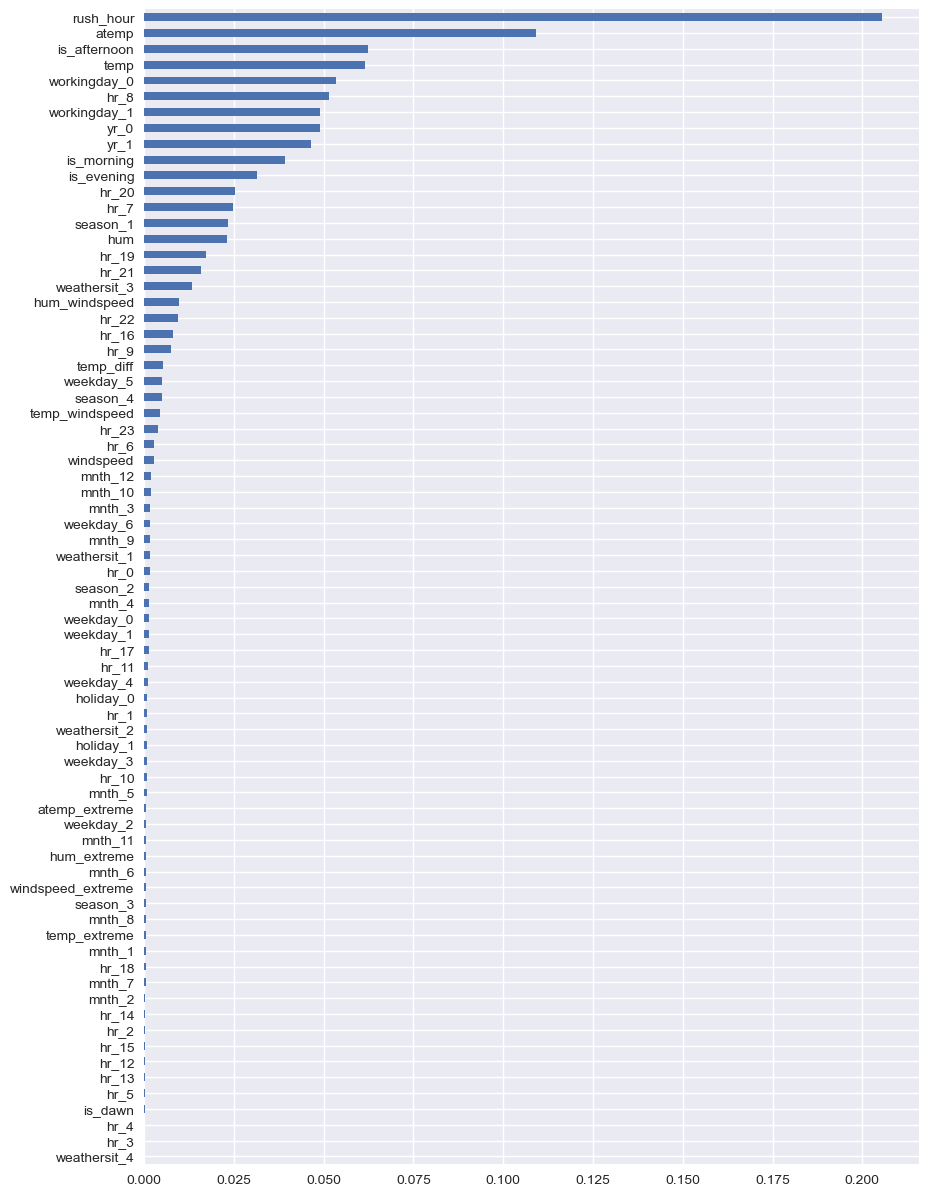

In [16]:
# step 1: find features with absolute correlation < 0.05
print('STEP 1: ------------------------------------')
correlation_matrix = pd.concat( [X_train_fe_scaled, y_train_fe_unscaled], axis=1 ).corr()
correlations = correlation_matrix['cnt'].abs().sort_values(ascending=False)
correlations = correlations.drop('cnt')
display(correlations[:15])


# step 2: Lasso zeroed-out features (from Lasso regression)
print('\nSTEP 2: ------------------------------------')
print("Features zeroed by Lasso:")
zeroed = X_train_fe_scaled.columns[lasso_sc.coef_ == 0].tolist()
if zeroed:
    for feature in zeroed:
        print(feature)
else:
    print("none at alpha=0.01")


# step 3: find pairs with absolute correlation > 0.85
print('\nSTEP 3: ------------------------------------')
correlation_matrix_abs = correlation_matrix.abs()
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range (i+1, len(correlation_matrix.columns)):
        if correlation_matrix_abs.iloc[i,j]>0.85:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i,j]))
high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature 1", "Feature 2", "Correlation"]
)
high_corr_df = high_corr_df.sort_values(by="Correlation", ascending=False).reset_index(drop=True)
print("Highly correlated feature pairs (>0.85):")
display(high_corr_df.sort_values(by='Feature 1'))


# step 4: RF feature importance 
print('\nSTEP 4: ------------------------------------')
importances = pd.Series(rf_unsc.feature_importances_, index=X_train_fe_unscaled.columns)
importances[:20]
importances.sort_values(ascending=True).plot.barh(figsize=(10, 15))

### Candidates for dropping
| Feature | Reason |
|---------|--------|
| `holiday_1` | redundant; information captured by `holiday_0`; 100% correlation to `holiday_0` (r=-1.000); low feature importance |
| `atemp` | redundant; correlated to `temp` (r=0.989) |
| `workingday_0` | redundant; information already captured by `workingday_1`; 100% correlated to `workingday_1` |
| `yr_0` | redundant; information captured by `yr_1`; 100% correlation to `yr_1` (r=-1.000) |


In [17]:
# features to drop
drop_cols = ['holiday_1', 'atemp', 'workingday_0', 'yr_0']

# drop only the columns that actually exist in this dataset
drop_cols = [c for c in drop_cols if c in X_train_fe_unscaled.columns]
print(f"Dropping: {drop_cols}")

X_train_refined = X_train_fe_unscaled.drop(columns=drop_cols)
X_test_refined = X_test_fe_unscaled.drop(columns=drop_cols)

# for linear models, re-scale the refined set
from sklearn.preprocessing import StandardScaler
scaler_refined = StandardScaler()
X_train_refined_scaled = pd.DataFrame(
    scaler_refined.fit_transform(X_train_refined), columns=X_train_refined.columns)
X_test_refined_scaled = pd.DataFrame(
    scaler_refined.transform(X_test_refined), columns=X_test_refined.columns)

print(f"Features: {X_train_fe_unscaled.shape[1]} → {X_train_refined.shape[1]}")

Dropping: ['holiday_1', 'atemp', 'workingday_0', 'yr_0']
Features: 73 → 69


### Compare performance after dropping

In [18]:
# re-train key models on refined feature set

# Linear Regression
lr_ref = LinearRegression()
lr_ref.fit(X_train_refined_scaled, y_train_fe_unscaled)

# Ridge Regression
ridge_ref = Ridge(alpha=10.0)
ridge_ref.fit(X_train_refined_scaled, y_train_fe_unscaled)

# Lasso Regression
lasso_ref = Lasso(alpha=0.01, max_iter=50000)
lasso_ref.fit(X_train_refined_scaled, y_train_fe_unscaled)

# Decision Tree
dt_ref = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt_ref.fit(X_train_refined_scaled, y_train_fe_unscaled)

# Random forest
rf_ref = RandomForestRegressor(n_estimators=100, max_depth=15, 
                               random_state=4950, n_jobs=-1)
rf_ref.fit(X_train_refined, y_train_fe_unscaled)

# Gradient boosting
gb_ref = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                   learning_rate=0.1, random_state=4950)
gb_ref.fit(X_train_refined, y_train_fe_unscaled)

comparison = pd.DataFrame([
    {'Model': 'Linear Regression', 
     'Full features': result_df.loc[result_df['Model']=='Linear Regression (baseline, scaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, lr_ref.predict(X_test_refined_scaled))} ,

    {'Model': 'Ridge Regression', 
     'Full features': result_df.loc[result_df['Model']=='Ridge (baseline, scaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, ridge_ref.predict(X_test_refined_scaled))} ,

    {'Model': 'Lasso Regression', 
     'Full features': result_df.loc[result_df['Model']=='Lasso (baseline, scaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, lasso_ref.predict(X_test_refined_scaled))} ,

    {'Model': 'Decision Tree', 
     'Full features': result_df.loc[result_df['Model']=='Decision Tree (baseline, unscaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, dt_ref.predict(X_test_refined_scaled))} ,

    {'Model': 'Random Forest', 
     'Full features': result_df.loc[result_df['Model']=='Random Forest (baseline, unscaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, rf_ref.predict(X_test_refined))} ,

    {'Model': 'Gradient Boosting', 
     'Full features': result_df.loc[result_df['Model']=='Gradient Boosting (baseline, unscaled data)', 'Test R²'].values[0],
     'Refined features': r2_score(y_test_fe_unscaled, gb_ref.predict(X_test_refined))} ,
])

comparison['R² change'] = comparison['Refined features'] - comparison['Full features']
comparison

,Model,Full features,Refined features,R² change
0,Linear Regression,0.714987,0.714987,0.000000
1,Ridge Regression,0.715142,0.714975,-0.000167
2,Lasso Regression,0.715224,0.714994,-0.000230
3,Decision Tree,0.884536,0.882964,-0.001572
4,Random Forest,0.940791,0.939323,-0.001468
5,Gradient Boosting,0.899949,0.900237,0.000288


### Observations

For the linear models, the R² values remained almost identical. This suggests that the removed features were either redundant or had very little linear relationship with the target variable. The models were already capturing most of the available signal, so refinement did not provide any meaningful improvement.

The tree-based models (Decision Tree and Random Forest) experienced slight decreases in performance. This indicates that these models may have been leveraging subtle patterns or interactions in the full feature set, even if those features were weak individually. Since tree-based models can capture nonlinear relationships, removing features can sometimes reduce their ability to model complex patterns.

Gradient Boosting is the only model that showed a slight improvement after feature refinement, although the gain is extremely small. This suggests that removing minor noise or redundant features may have helped the model generalize slightly better.

## 5. Cross Validation

Linear Regression:
mean=0.7100  std=0.0019  folds=[0.707 0.713 0.71  0.709 0.711]

Ridge Regression:
mean=0.7100  std=0.0019  folds=[0.707 0.713 0.71  0.709 0.711]

Lasso Regression:
mean=0.7100  std=0.0019  folds=[0.707 0.713 0.71  0.709 0.711]

Decision Tree:
mean=0.8908  std=0.0114  folds=[0.886 0.911 0.879 0.894 0.883]

Random Forest:
mean=0.9370  std=0.0052  folds=[0.936 0.946 0.935 0.937 0.931]

Gradient Boosting:
mean=0.8907  std=0.0065  folds=[0.888 0.903 0.885 0.891 0.886]



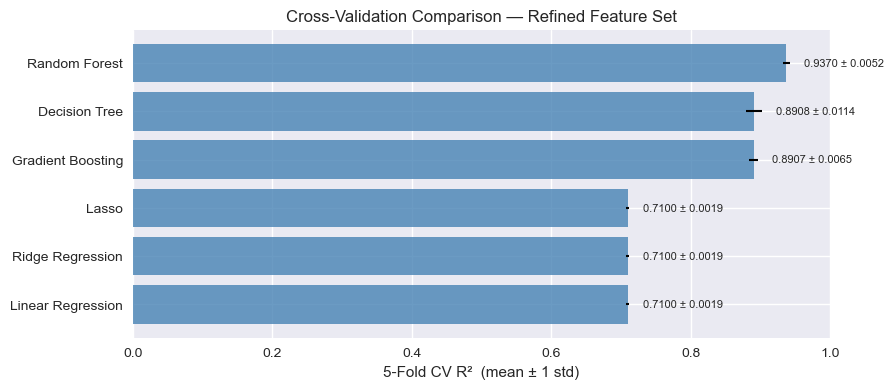

In [19]:
# define cv strategy
cv = KFold(n_splits=5, shuffle=True, random_state=4950)

# define empty list for cv results
cv_results = []

# Linear Regression
lr_pipe = make_pipeline( StandardScaler(), LinearRegression() )
scores = cross_val_score( lr_pipe, 
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1 )
cv_results.append({'Model': 'Linear Regression','CV Mean R²': scores.mean().round(4),'CV Std': scores.std().round(4)})
print("Linear Regression:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")


# Ridge Regression
ridge_cv = Ridge()
ridge_pipe = make_pipeline( StandardScaler(), Ridge(alpha=10.0) )
scores = cross_val_score( ridge_pipe, 
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Ridge Regression', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print("\nRidge Regression:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")


# Lasso Regression
lasso_pipe = make_pipeline( StandardScaler(), Lasso(alpha=0.01, max_iter=50000) )
scores = cross_val_score( lasso_pipe, 
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Lasso', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print("\nLasso Regression:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")


# Decision Tree
dt_cv = DecisionTreeRegressor(max_depth=10, random_state=4950)
scores = cross_val_score( dt_cv,      
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Decision Tree', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print("\nDecision Tree:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")


# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=15, 
                              random_state=4950, n_jobs=-1)
scores = cross_val_score( rf_cv,      
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Random Forest', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print("\nRandom Forest:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}")


# Gradient Boosting
gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                                  learning_rate=0.1, random_state=4950)
scores = cross_val_score( gb_cv,      
                        X_train_refined, y_train_fe_unscaled, 
                        cv=cv, scoring='r2', n_jobs=-1)
cv_results.append({'Model': 'Gradient Boosting', 'CV Mean R²': scores.mean().round(4), 'CV Std': scores.std().round(4)})
print("\nGradient Boosting:")
print(f"mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,3)}\n")  


# visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)
# display(cv_df)
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison — Refined Feature Set')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.02,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.show()

### Observations

The cross-validation mean scores are consistent with the test-set results from Section 2. The overall ranking of the models remains the same: Random Forest performs the best while the linear models perform the worst. 

The linear models have identical CV means and very low standard deviation, indicating both low variance and stable performance across folds. However, their lower scores confirm that they are underfitting the data.

Among the tree-based models, Random Forest achieves the highest CV mean, closely matching its strong test-set R². Its relatively low standard deviation indicates that it is also stable and consistent across different data splits. Decision Tree and Gradient Boosting have similar CV means, which aligns with their test-set performance. Their standard deviations are slightly higher than Random Forest but still low, suggesting moderate variability while remaining generally reliable.

Our main takeaway is that Random Forest is the strongest model, tree-based methods outperform linear models, and all models demonstrate stable performance across folds.

## 6. Hyperparameter Tuning with GridSearchCV

### Ridge - tuning the regularization strength $\alpha$

   alpha  mean_R²   std_R²
   0.001 0.709971 0.001857
   0.010 0.709971 0.001857
   0.100 0.709971 0.001857
   1.000 0.709971 0.001856
  10.000 0.709978 0.001855
 100.000 0.709992 0.001852
1000.000 0.707419 0.002318


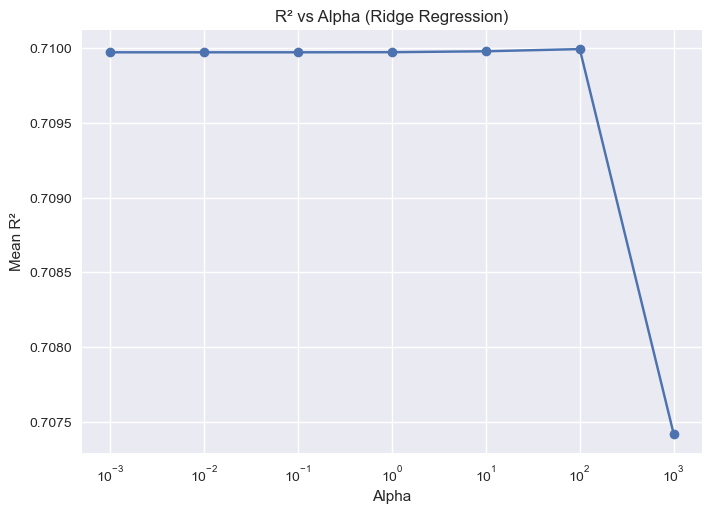

Best alpha: 100
CV R² with best alpha: 0.709992

MODEL: Ridge Regression (scaled, tuned)
	Train: R² = 0.7128, RMSE = 97.2871
	Test:  R² = 0.7149, RMSE = 96.5454



In [20]:
# perform the GridSearchCV using make_pipeline
ridge_pipe = make_pipeline( StandardScaler(), Ridge() )
ridge_grid = GridSearchCV(ridge_pipe,
                         param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
                         cv=cv,
                         scoring='r2', n_jobs= -1)
ridge_grid.fit(X_train_refined, y_train_fe_unscaled)

# Show how R² changes across alpha values
ridge_cv_df = pd.DataFrame(ridge_grid.cv_results_)[['param_ridge__alpha', 'mean_test_score', 'std_test_score']]
ridge_cv_df.columns = ['alpha', 'mean_R²', 'std_R²']
print(ridge_cv_df.round(6).to_string(index=False))
plt.figure()
plt.plot(ridge_cv_df['alpha'], ridge_cv_df['mean_R²'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean R²')
plt.title('R² vs Alpha (Ridge Regression)')
plt.xscale('log') 
plt.show()

print(f"Best alpha: {ridge_grid.best_params_['ridge__alpha']}")
print(f'CV R² with best alpha: {ridge_grid.best_score_:.6f}\n')

model_metrics(
    ridge_grid,
    'Ridge Regression (scaled, tuned)',
    X_train_refined, y_train_fe_unscaled,
    X_test_refined, y_test_fe_unscaled,
    results
)

### Random Forest - tuning depth and feature sampling

In [21]:
# define parameter grid
param_grid = {
        'n_estimators': [100, 200],
        'max_depth':    [8, 12, 15, None],
        'max_features': ['sqrt', 0.5],
    }
rf_grid = GridSearchCV(RandomForestRegressor(random_state=4950, n_jobs=-1),
                      param_grid = param_grid,
                      cv = cv, scoring = 'r2', n_jobs = -1)
rf_grid.fit(X_train_refined, y_train_fe_unscaled)

print(f"Best params: {rf_grid.best_params_}")
print(f"CV R²:       {rf_grid.best_score_:.4f}")
print()

# Top 5 combinations
rf_cv_df = (pd.DataFrame(rf_grid.cv_results_)
            [['param_max_depth', 'param_max_features', 'mean_test_score', 'std_test_score']]
            .sort_values('mean_test_score', ascending=False)
            .head(5))
rf_cv_df.columns = ['max_depth', 'max_features', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(rf_cv_df.round(6).to_string(index=False))

print()
model_metrics(
    rf_grid,
    'Random Forest (tuned)',
    X_train_refined, y_train_fe_unscaled,
    X_test_refined, y_test_fe_unscaled,
    results
)

Best params: {'max_depth': None, 'max_features': 0.5, 'n_estimators': 200}
CV R²:       0.9392

Top 5 combinations:
max_depth max_features  mean_R²   std_R²
     None          0.5 0.939204 0.005281
     None          0.5 0.938544 0.005474
       15          0.5 0.935001 0.005219
       15          0.5 0.934482 0.005222
       12          0.5 0.923797 0.005434

MODEL: Random Forest (tuned)
	Train: R² = 0.9921, RMSE = 16.0946
	Test:  R² = 0.9440, RMSE = 42.7863



### Gradient Boosting - tuning learning rate and depth

In [22]:
# define parameter grid
param_grid={
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 4, 5],
    }
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=4950),
                      param_grid=param_grid,
                       cv=cv, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train_refined, y_train_fe_unscaled)

print(f"Best params: {gb_grid.best_params_}")
print(f"CV R²:       {gb_grid.best_score_:.4f}")
print()

# Top 5 combinations
gb_cv_df = (pd.DataFrame(gb_grid.cv_results_)
            [['param_n_estimators', 'param_learning_rate', 'param_max_depth',
              'mean_test_score', 'std_test_score']]
            .sort_values('mean_test_score', ascending=False)
            .head(5))
gb_cv_df.columns = ['n_est', 'lr', 'max_depth', 'mean_R²', 'std_R²']
print("Top 5 combinations:")
print(gb_cv_df.round(4).to_string(index=False))

print()
model_metrics(
    gb_grid,
    'Gradient Boosting (tuned)',
    X_train_refined, y_train_fe_unscaled,
    X_test_refined, y_test_fe_unscaled,
    results
)

Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
CV R²:       0.9371

Top 5 combinations:
 n_est  lr  max_depth  mean_R²  std_R²
   200 0.2          5   0.9371  0.0056
   200 0.1          5   0.9326  0.0028
   100 0.2          5   0.9312  0.0047
   200 0.2          4   0.9295  0.0050
   200 0.1          4   0.9178  0.0051

MODEL: Gradient Boosting (tuned)
	Train: R² = 0.9721, RMSE = 30.3418
	Test:  R² = 0.9407, RMSE = 44.0388



### Tuning Summary: Default vs Tuned

In [23]:
# table of all models + metrics ------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)
print('All Models')
print('=' * 120)
print(results_df.to_string(index=False))


# table of default vs tuned models ---------------------------------------------
comparison_tune_scaling = pd.DataFrame([
    {'Model': 'Ridge Regression', 
     'Default': results_df.loc[results_df['Model']=='Ridge (baseline, scaled data)', 'Test R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Ridge Regression (scaled, tuned)', 'Test R²'].values[0]},
    {'Model': 'Random Forest',
    'Default': results_df.loc[results_df['Model']=='Random Forest (baseline, unscaled data)', 'Test R²'].values[0],
    'Tuned': results_df.loc[results_df['Model']=='Random Forest (tuned)', 'Test R²'].values[0]},
    {'Model': 'Gradient Boosting',
    'Default': results_df.loc[results_df['Model']=='Gradient Boosting (baseline, unscaled data)', 'Test R²'].values[0],
     'Tuned': results_df.loc[results_df['Model']=='Gradient Boosting (tuned)', 'Test R²'].values[0]},
])
comparison_tune_scaling['Δ R²'] = (comparison_tune_scaling['Tuned'] - comparison_tune_scaling['Default']).round(4)
comparison_tune_scaling[['Default', 'Tuned']] = comparison_tune_scaling[['Default', 'Tuned']].round(4)
print()
print('Comparison of default vs tuned models')
print('=' * 45)
print(comparison_tune_scaling.to_string(index=False))


# table of CV scores ---------------------------------------------
# 1. compute CV scores (test scores already in results_df)
ridge_cv = cross_val_score(ridge_grid.best_estimator_, X_train_fe_scaled, y_train_fe_unscaled, cv=cv, scoring='r2', n_jobs=-1)
rf_cv    = cross_val_score(rf_grid.best_estimator_, X_train_fe_unscaled, y_train_fe_unscaled, cv=cv, scoring='r2', n_jobs=-1)
gb_cv    = cross_val_score(gb_grid.best_estimator_, X_train_fe_unscaled, y_train_fe_unscaled, cv=cv, scoring='r2', n_jobs=-1)

# 2. pull test scores directly from results_df
ridge_row = results_df[results_df['Model'] == 'Ridge Regression (scaled, tuned)'].iloc[0]
rf_row    = results_df[results_df['Model'] == 'Random Forest (tuned)'].iloc[0]
gb_row    = results_df[results_df['Model'] == 'Gradient Boosting (tuned)'].iloc[0]

# 3. compile into table
final_df = pd.DataFrame({
    'Model':      ['Ridge (scaled, tuned)', 'Random Forest (tuned)', 'Gradient Boosting (tuned)'],
    'CV R² mean': [ridge_cv.mean(), rf_cv.mean(), gb_cv.mean()],
    'CV R² std':  [ridge_cv.std(),  rf_cv.std(),  gb_cv.std()],
    'Test R²':    [ridge_row['Test R²'], rf_row['Test R²'], gb_row['Test R²']],
    'Test RMSE':  [ridge_row['Test RMSE'], rf_row['Test RMSE'], gb_row['Test RMSE']],
}).round(4).sort_values('Test R²', ascending=False)
print()
print('Table of CV info')
print('=' * 70)
print(final_df.to_string(index=False))

All Models
                                               Model  Train RMSE  Test RMSE  RMSE Δ (Test-Train)  Train R²  Test R²  R² Δ (Test-Train)
                               Random Forest (tuned)   16.094611  42.786260            26.691649  0.992139 0.943997          -0.048142
             Random Forest (baseline, unscaled data)   21.671267  43.993977            22.322710  0.985748 0.940791          -0.044956
                           Gradient Boosting (tuned)   30.341846  44.038774            13.696927  0.972061 0.940671          -0.031391
         Gradient Boosting (baseline, unscaled data)   55.596138  57.188732             1.592594  0.906198 0.899949          -0.006249
             Decision Tree (baseline, unscaled data)   48.596504  61.436011            12.839507  0.928331 0.884536          -0.043795
                       Lasso (baseline, scaled data)   97.286131  96.483139            -0.802992  0.712774 0.715224           0.002450
                       Ridge (baseline, scal

### Observations

- Tuned Random Forest has a very low training RMSE (\~16.09) and a higher test RMSE (\~42.79), with a drop in R² from \~0.992 (train) to \~0.944 (test). This gap indicates overfitting, as the model fits the training data extremely well but does not generalize perfectly to unseen data. However, the test performance is still strong, and the improvement over the baseline suggests that tuning was beneficial despite the overfitting.

- Tuned Gradient Boosting shows a smaller gap between training and test performance compared to Random Forest. Its training RMSE (\~30.34) and test RMSE (\~44.04), along with the R² decrease from \~0.972 to \~0.941, indicate moderate overfitting, but significantly less than Random Forest. This suggests better generalization while still achieving strong performance gains over the baseline.

- Tuned Ridge Regression shows almost no difference between training and test metrics. The RMSE values (\~97.29 vs \~96.55) and nearly identical R² values (\~0.713 vs \~0.715) indicate no overfitting, but instead underfitting, as the model is too simple to capture the complexity of the data.

## 7. Model Selection

In [25]:
# add identifier
final_results_df = pd.DataFrame(results).copy()
final_results_df["Model Type"] = np.where(final_results_df["Model"].str.contains("tuned"), "Tuned", "Default")

final_results_df = final_results_df.sort_values("Test R²", ascending=False).reset_index(drop=True)
display(final_results_df)

,Model,Train RMSE,Test RMSE,RMSE Δ (Test-Train),Train R²,Test R²,R² Δ (Test-Train),Model Type
0,Random Forest (tuned),16.094611,42.786260,26.691649,0.992139,0.943997,-0.048142,Tuned
1,"Random Forest (baseline, unscaled data)",21.671267,43.993977,22.322710,0.985748,0.940791,-0.044956,Default
2,Gradient Boosting (tuned),30.341846,44.038774,13.696927,0.972061,0.940671,-0.031391,Tuned
3,"Gradient Boosting (baseline, unscaled data)",55.596138,57.188732,1.592594,0.906198,0.899949,-0.006249,Default
4,"Decision Tree (baseline, unscaled data)",48.596504,61.436011,12.839507,0.928331,0.884536,-0.043795,Default
5,"Lasso (baseline, scaled data)",97.286131,96.483139,-0.802992,0.712774,0.715224,0.002450,Default
6,"Ridge (baseline, scaled data)",97.298495,96.497045,-0.801451,0.712701,0.715142,0.002441,Default
7,"Linear Regression (baseline, unscaled data)",97.281962,96.523361,-0.758602,0.712799,0.714987,0.002188,Default
8,"Linear Regression (baseline, scaled data)",97.281962,96.523361,-0.758602,0.712799,0.714987,0.002188,Default
9,"Ridge Regression (scaled, tuned)",97.287065,96.545373,-0.741693,0.712769,0.714857,0.002088,Tuned


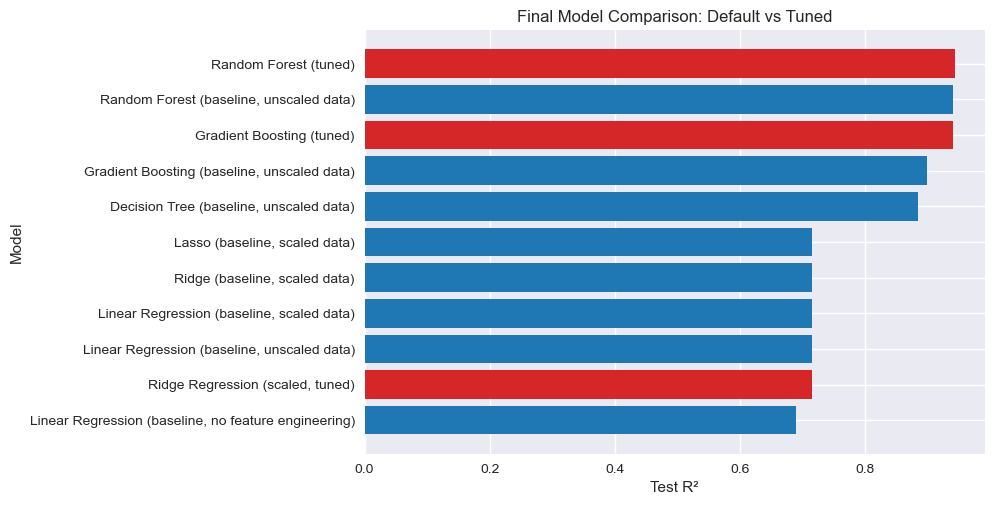

In [27]:
plot_df = final_results_df.sort_values("Test R²", ascending=True)

colors = {"Default": "tab:blue", "Tuned": "tab:red"}
bar_colors = plot_df["Model Type"].map(colors)

plt.figure()
plt.barh(plot_df["Model"], plot_df["Test R²"], color=bar_colors)
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.title("Final Model Comparison: Default vs Tuned")
plt.show()

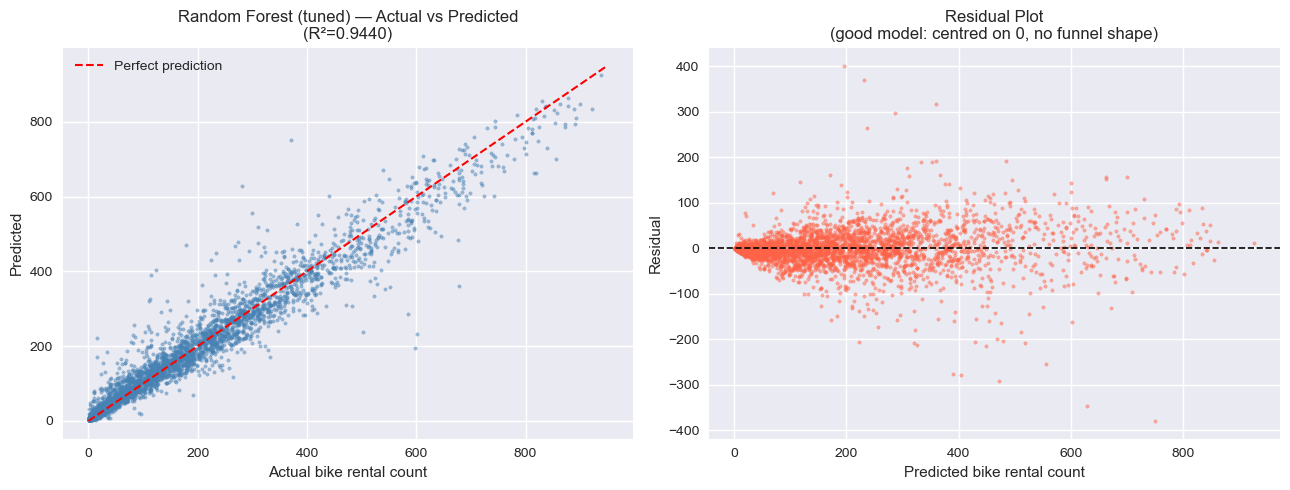

In [28]:
best_model  = rf_grid.best_estimator_   # swap to rf_grid if RF wins
best_name   =  'Random Forest (tuned)'
y_pred_best = best_model.predict(X_test_refined)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(y_test_fe_unscaled, y_pred_best, alpha=0.5, s=6, color='steelblue')
lims = [0, 950]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual bike rental count')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_name} — Actual vs Predicted\n(R²={r2_score(y_test_fe_unscaled, y_pred_best):.4f})')
axes[0].legend()

# residual plot
residuals = y_test_fe_unscaled - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=6, color='tomato')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Predicted bike rental count')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot\n(good model: centred on 0, no funnel shape)')

plt.tight_layout()
plt.show()

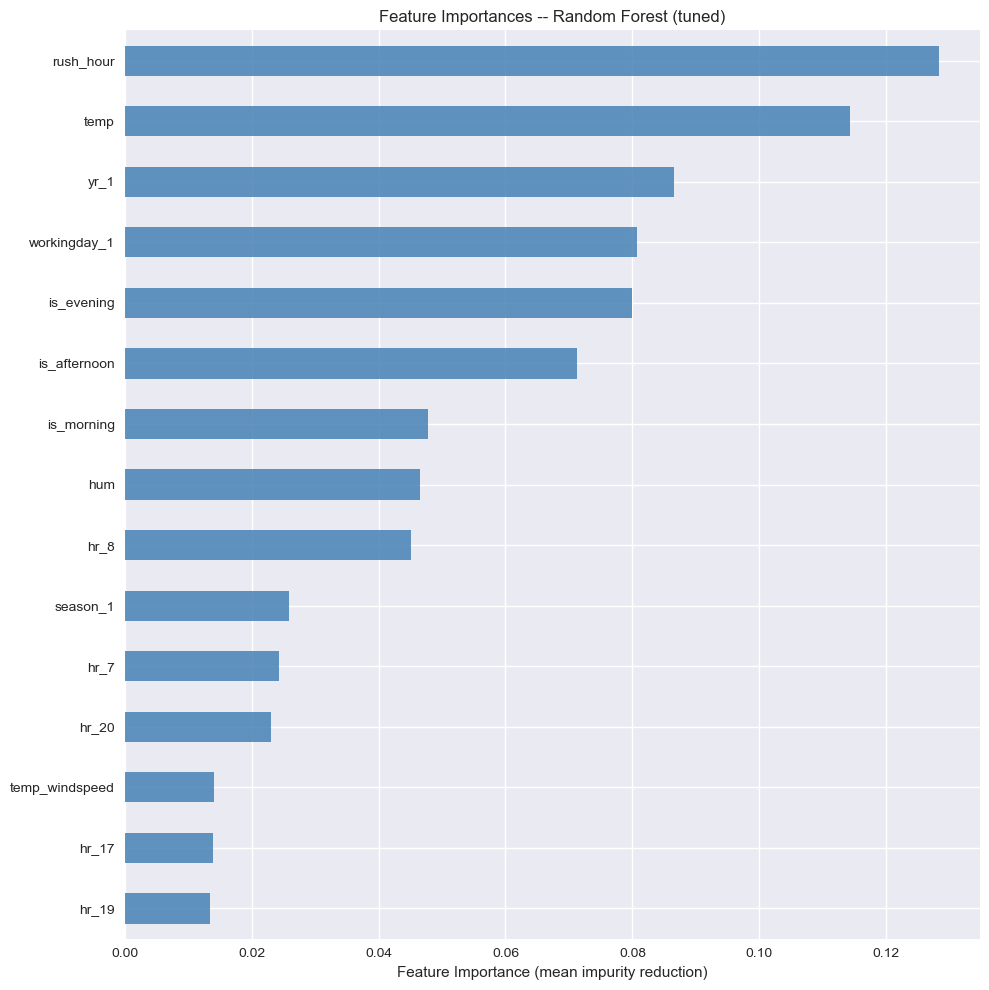

Top 15 most important features:
rush_hour         0.1283
temp              0.1143
yr_1              0.0866
workingday_1      0.0806
is_evening        0.0799
is_afternoon      0.0712
is_morning        0.0478
hum               0.0465
hr_8              0.0451
season_1          0.0258
hr_7              0.0243
hr_20             0.0231
temp_windspeed    0.0141
hr_17             0.0140
hr_19             0.0135


In [29]:
# feature importance — best tree model
importances = pd.Series(best_model.feature_importances_,
                        index=X_train_refined.columns)   # <- refined columns, not full X_train
importances_sorted = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 10))
importances_sorted.plot.barh(ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Feature Importance (mean impurity reduction)')
ax.set_title(f'Feature Importances -- {best_name}')
plt.tight_layout()
plt.show()

print("Top 15 most important features:")
print(importances.sort_values(ascending=False).head(15).round(4).to_string())

### Observations





The winning model is the **Tuned Random Forest**, since it achieves the best overall predictive performance across both validation and test evaluations.

On the test set, the Tuned Random Forest yields:

* Test R² = 0.9440
* Test RMSE = 42.79

This is the strongest test performance among all models, indicating the best generalization to unseen data.

Cross-validation results further support its stability and reliability:

* CV R² mean = 0.9393 ± 0.0058

The low standard deviation shows consistent performance across folds, meaning the model is not highly sensitive to data splits.

In terms of improvement over the best baseline model, the Tuned Random Forest shows clear gains:

* Baseline Random Forest Test R² = 0.9408 → Tuned = 0.9440
* Δ R² = +0.0032
* Test RMSE improves from 43.99 → 42.79

## 8. Save best model

In [25]:
# save best model
import pickle, os
os.makedirs('../models', exist_ok=True)

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Saved:  ../models/best_model.pkl')
print(f"Model : {type(best_model).__name__}")
print(f"Params: {gb_grid.best_params_}")
print(f"Test R2: {r2_score(y_test_fe_unscaled, y_pred_best):.4f}")
print(f"Test RMSE: ${np.sqrt(mean_squared_error(y_test_fe_unscaled, y_pred_best)):,.0f}")

Saved:  ../models/best_model.pkl
Model : RandomForestRegressor
Params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Test R2: 0.9440
Test RMSE: $43


## Key Findings Summary

1. **Random Forest** is the best-performing model, achieving the highest test performance with **R² ≈ 0.944** and the lowest **RMSE (\~42.79)** after tuning.
2. The clearest overfitting pattern occurred in the **Random Forest model**, where training **R² = 0.9857** but test **R² = 0.9408**, a gap of approximately **0.0449**.
3. The strongest cross-validation result came from **Random Forest (tuned)**, with a **mean CV R² of 0.9393 ± 0.0058**, indicating strong and consistent performance across folds.
4. The final selected model, **Random Forest (Tuned)**, delivered the strongest overall results with a test-set **R² of 0.9440** and **RMSE of 42.79**. Compared to the best default model, it improved performance by +0.0032 R² points and reduced RMSE from 43.99 to 42.79.
5. The saved winning model was successfully reloaded and used to generate predictions on the test set, confirming that the full training and deployment pipeline worked properly.